In [1]:
%load_ext autoreload
%autoreload 2

from copy import deepcopy
import torch
from transformers import T5Tokenizer, T5EncoderModel
import os
from os.path import join
import torch
import torch as th
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pkl
import pandas as pd
import cv2
import pandas as pd
import numpy as np
from tqdm.auto import trange
from contextlib import redirect_stdout
import sys
sys.path.append("/n/home12/binxuwang/Github/DiffusionObjectRelation/PixArt-alpha")
from diffusion.model.builder import build_model
from diffusion.utils.misc import set_random_seed, read_config, init_random_seed, DebugUnderflowOverflow
sys.path.append("/n/home12/binxuwang/Github/DiffusionObjectRelation")
from utils.pixart_sampling_utils import pipeline_inference_custom, \
    PixArtAlphaPipeline_custom
from utils.pixart_utils import state_dict_convert
from utils.pixart_utils import construct_diffuser_pipeline_from_config
from utils.cv2_eval_utils import find_classify_objects, evaluate_parametric_relation, eval_func_factory, scene_info_collection
from utils.cv2_eval_utils import evaluate_pipeline_on_prompts, print_evaluation_summary
from utils.relation_shape_dataset_lib import ShapesDataset
from experimental_scripts.generalization_profile_eval_cli import evaluate_pipeline_on_prompts_with_cached_embeddings, precompute_embeddings
from circuit_toolkit.plot_utils import saveallforms
from utils.variance_partition_with_effects import variance_partition_with_effects

/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(
/n/home12/binxuwang/.conda/envs/torch2/lib/python3.10/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.i

In [2]:
from experimental_scripts.generalization_profile_eval_cli import evaluate_pipeline_on_prompts_with_cached_embeddings, precompute_embeddings
def find_shape_index(tokens, shape):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = shape.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = shape.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

def find_word_index(tokens, word):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = word.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = word.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

from itertools import product
def generate_prompt_collection(spatial_phrases, 
                               prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",
                               color1="blue", shape1="circle", color2="red", shape2="square"):
    prompt_collection = []
    scene_info_collection = []
    for spatial_relationship, rel_text_collection in spatial_phrases.items():
        if spatial_relationship in ["in_front", "behind"]:
            continue
        for rel_text in rel_text_collection:
            prompt = prompt_template.format(color1=color1, shape1=shape1, rel_text=rel_text, color2=color2, shape2=shape2)
            scene_info = {
                "color1": color1,
                "shape1": shape1,
                "color2": color2,
                "shape2": shape2,
                "spatial_relationship": spatial_relationship
            }
            prompt_collection.append(prompt)
            scene_info_collection.append(scene_info)
    return prompt_collection, scene_info_collection


def generate_all_prompt_collection(spatial_phrases, 
                               prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",):
    color_list = ['red', 'blue']
    shape_list = ['square', 'triangle', 'circle']
    prompt_collection = []
    scene_info_collection = []
    for color1, color2 in product(color_list, color_list):
        if color1 == color2:      # skip same‐color pairs
            continue
        for shape1, shape2 in product(shape_list, shape_list):
            if shape1 == shape2:
                continue
            for spatial_relationship, rel_text_collection in spatial_phrases.items():
                if spatial_relationship in ["in_front", "behind"]:
                    continue
                for rel_text in rel_text_collection:
                    prompt = prompt_template.format(color1=color1, shape1=shape1, rel_text=rel_text, color2=color2, shape2=shape2)
                    scene_info = {
                        "color1": color1,
                        "shape1": shape1,
                        "color2": color2,
                        "shape2": shape2,
                        "spatial_relationship": spatial_relationship
                    }
                    prompt_collection.append(prompt)
                    scene_info_collection.append(scene_info)
    return prompt_collection, scene_info_collection

In [3]:
model_run_name = "objrel_T5_DiT_B_pilot" # "objrel_rndembdposemb_DiT_B_pilot" 
# model_run_name = "objrel_T5_DiT_mini_pilot_WDecay" # "objrel_rndembdposemb_DiT_B_pilot" 
# ckpt_name = "epoch_4000_step_160000.pth" # "epoch_4000_step_160000.pth" 
ckpt_name = "epoch_4000_step_160000.pth"  # "epoch_4000_step_160000.pth" 
text_encoder_type = "T5" 
savedir = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/results/{model_run_name}"
config = read_config(join(savedir, 'config.py'))
# Build pipeline from config
pipeline = construct_diffuser_pipeline_from_config(config, pipeline_class=PixArtAlphaPipeline_custom)
text_feat_dir_old = '/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/training_datasets/random_emd_dictionary'
T5_path = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/PixArt/output/pretrained_models/t5_ckpts/t5-v1_1-xxl"
tokenizer = T5Tokenizer.from_pretrained(T5_path, )#subfolder="tokenizer")
if text_encoder_type == "T5":
    text_encoder = T5EncoderModel.from_pretrained(T5_path, load_in_8bit=False, torch_dtype=torch.bfloat16, )
    
ckptdir = join(savedir, "checkpoints")

ckpt = torch.load(join(ckptdir, ckpt_name))
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
# pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict']))
pipeline.tokenizer = tokenizer
pipeline.to(device="cuda", dtype=torch.float16);
pipeline.text_encoder = text_encoder.to(device="cuda", )
ckpt_name = "epoch_4000_step_160000.pth"  # "epoch_4000_step_160000.pth" 
ckpt = torch.load(join(ckptdir, ckpt_name))
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))

weight_dtype: torch.float16


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

Expected types for transformer: (<class 'diffusers.models.transformers.pixart_transformer_2d.PixArtTransformer2DModel'>,), got <class 'diffusers.models.transformers.transformer_2d.Transformer2DModel'>.
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_883483/4291171337.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(join(ckptdir, ckpt_name))
/tmp/ipykernel_883483/4291171337.py:25: Fut

<All keys matched successfully>

In [4]:
manip_figdir = f"/n/home12/binxuwang/Github/DiffusionObjectRelation/Figures/DiT_T5_wordvec_grafting/{model_run_name}"
os.makedirs(manip_figdir, exist_ok=True)

In [5]:
prompt = "blue circle is to the lower left of red square"
scene_info = {'color1': 'blue',
  'shape1': 'circle',
  'color2': 'red',
  'shape2': 'square',
  'spatial_relationship': 'lower_left'}
embedding_cache = precompute_embeddings({"base":([prompt], [scene_info])}, 
                                        pipeline.tokenizer, pipeline.text_encoder, 
                                        max_sequence_length=20, device="cuda")

Pre-computing text embeddings for all prompts...
Computing unconditional embedding...


Computing embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Cached embeddings for 2 unique prompts (including uncond)


In [7]:
dataset_tmp = ShapesDataset(num_images=10000)
prompt_collection_all, scene_info_collection_all = generate_all_prompt_collection(dataset_tmp.spatial_phrases,
                                prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",)
embedding_allrel_allobj = precompute_embeddings({"base":(prompt_collection_all, scene_info_collection_all)}, 
                                        pipeline.tokenizer, pipeline.text_encoder, 
                                        max_sequence_length=20, device="cuda")
prompt_scene_info_all_df = pd.DataFrame(scene_info_collection_all)
prompt_scene_info_all_df["prompt"] = prompt_collection_all
prompt_scene_info_all_df
wordvec_obj1_col = []
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    token_ids = tokenized['input_ids'][0]
    tokens = [pipeline.tokenizer.decode([token_id]) for token_id in token_ids]
    
    shape1_mask_idx = find_shape_index(tokens, row.shape1)
    shape2_mask_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    if shape1_mask_idx is None or shape2_mask_idx is None:
        print(f"Prompt: {row.prompt}")
        print(f"Shape1 ({row.shape1}) at index: {shape1_mask_idx}")
        print(f"Shape2 ({row.shape2}) at index: {shape2_mask_idx}")
        print("---")
        raise ValueError("Shape index not found")
    wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
    wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)

Pre-computing text embeddings for all prompts...
Computing unconditional embedding...


Computing embeddings:   0%|          | 0/265 [00:00<?, ?it/s]

Cached embeddings for 265 unique prompts (including uncond)


In [8]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.748614
Total R² (all features): 0.7486


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color2shape2,6,5,249,4291.094789,2479.828784,0.577901,1884.943290,0.439269,0.636018,0.009901
1,spatial_relationship,8,7,249,4291.094789,517.811992,0.120671,517.811992,0.120671,0.324336,0.009901
2,shape1,3,2,249,4291.094789,809.619660,0.188674,214.734166,0.050042,0.166016,0.009901


In [9]:
def print_evaluation_summary_concise(eval_df, group_by_prompt=True, show=True):
    print_df = eval_df.select_dtypes(include=['number', 'bool']).drop(columns=['prompt_id', 'sample_id'], errors='ignore').mean().round(3).to_frame().T
    if show:
        display(print_df)
    return print_df

In [10]:
def visualize_eval_df_object_relation(eval_df, figsize=(5, 5), title=None):
    figh = plt.figure(figsize=figsize)
    sns.scatterplot(x="x1", y="y1", color="blue", data=eval_df, label="object 1")
    sns.scatterplot(x="x2", y="y2", color="red", data=eval_df, label="object 2")
    
    # Draw lines between x1y1 and x2y2 for each pair - vectorized approach
    plt.plot([eval_df['x1'], eval_df['x2']], [eval_df['y1'], eval_df['y2']], 'k-', alpha=0.3, linewidth=0.5)
    plt.xlabel("object x")
    plt.ylabel("object y")
    plt.xlim(0, 128)
    plt.ylim(128, 0)
    if title is not None:
        plt.title(title)
    plt.gca().set_aspect('equal')
    # plt.show()
    return figh

In [22]:
def visualize_eval_df_object_relation_with_marker(
    eval_df,
    figsize=(5, 5),
    title=None,
    obj1_marker="circle",  # "o" for circle, "s" for square, "^" for triangle, etc.
    obj2_marker="square",
    obj1_color="blue",
    obj2_color="red",
    obj1_label=None,
    obj2_label=None,
    alpha=0.8,
):
    """
    Visualize object relation evaluation dataframe.
    
    Arguments:
        eval_df: DataFrame with columns x1, y1, x2, y2
        obj1_marker: Marker style for object 1 ('o'=circle, 's'=square, '^'=triangle, etc)
        obj2_marker: Marker style for object 2
        obj1_label: Legend label for object 1
        obj2_label: Legend label for object 2
        obj1_color: Color for object 1
        obj2_color: Color for object 2
    """
    if obj1_label is None:
        obj1_label = f"object 1: {obj1_color} {obj1_marker}"
    if obj2_label is None:
        obj2_label = f"object 2: {obj2_color} {obj2_marker}"
    marker_mapping = {
        "circle": "o",
        "square": "s",
        "triangle": "^"
    }
    figh = plt.figure(figsize=figsize)
    plt.scatter(eval_df["x1"], eval_df["y1"], c=obj1_color, s=64, marker=marker_mapping[obj1_marker], label=obj1_label, alpha=alpha)
    plt.scatter(eval_df["x2"], eval_df["y2"], c=obj2_color, s=64, marker=marker_mapping[obj2_marker], label=obj2_label, alpha=alpha)
    
    # Draw lines between x1y1 and x2y2 for each pair - vectorized approach
    plt.plot([eval_df['x1'], eval_df['x2']], [eval_df['y1'], eval_df['y2']], 'k-', alpha=0.3, linewidth=0.5)
    plt.xlabel("object x")
    plt.ylabel("object y")
    plt.xlim(0, 128)
    plt.ylim(128, 0)
    if title is not None:
        plt.title(title)
    plt.gca().set_aspect('equal')
    plt.legend()
    return figh

In [11]:
def get_feature_effect_vecs(effect_vecs, levels_map, feature, level):
    idx = list(levels_map[feature]).index(level)
    return effect_vecs[feature][idx, :]

get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "above")

array([ 0.01484235, -0.0436124 , -0.03554326, ...,  0.00121265,
       -0.00680394,  0.01186751])

In [12]:
above_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "above")).to(dtype=torch.bfloat16)
lower_left_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "lower_left")).to(dtype=torch.bfloat16)
lower_right_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "lower_right")).to(dtype=torch.bfloat16)
upper_right_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "upper_right")).to(dtype=torch.bfloat16)

blue circle is to the lower left of red square
without attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408


with attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,33.531,48.918,66.796,79.51,33.265,30.592


,,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
manipulated_token,manipulated_idx,,,,,,,,,,,,,,
,-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408
▁square,9,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,33.531,48.918,66.796,79.510,33.265,30.592


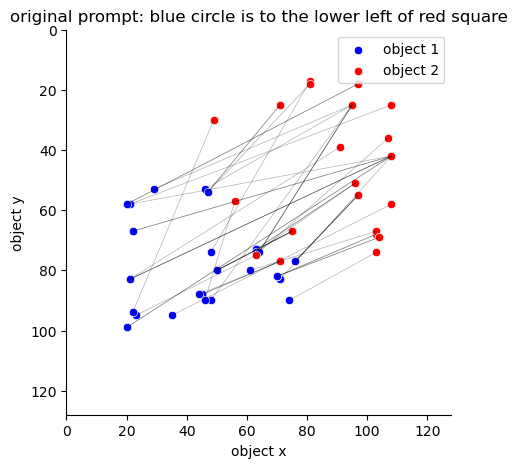

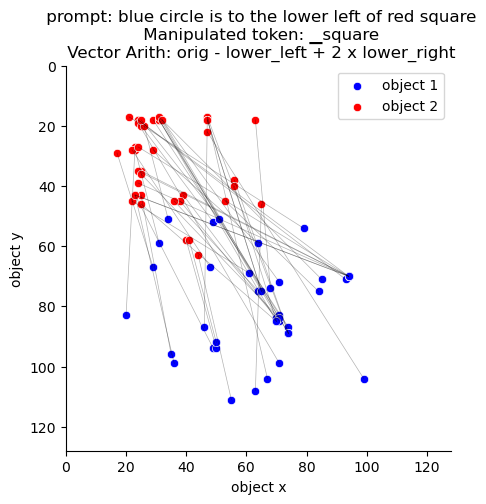

In [13]:
# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == 'blue circle is to the upper right of red square'").index
# alternate_prompt = "blue triangle is to the lower left of red square"# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == 'blue circle is to the upper right of red square'").index
# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == @alternate_prompt").index
# alt_wordvec = wordvec_obj2_mat[alt_prompt_idx, :]
print(prompt)
token_ids = pipeline.tokenizer.encode(prompt, add_special_tokens=True)
token_list = pipeline.tokenizer.convert_ids_to_tokens(token_ids)
target_token_idx = find_word_index(token_list, "square")
formula = "orig - lower_left + 2 x lower_right"
caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
target_wordvec = caption_embeds_tmp[0, [target_token_idx], :] - lower_left_effect_vec + 2 * lower_right_effect_vec

pipeline.set_progress_bar_config(disable=True)

summary_eval_df_list = []
print("without attention masking ", embedding_cache[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(pipeline, [prompt], [scene_info], embedding_cache,
                                                       num_images=49, num_inference_steps=14, guidance_scale=4.5,
                                                       generator_seed=42, color_margin=25, spatial_threshold=5, 
                                                       device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation(eval_df, title=f"original prompt: {prompt}")
saveallforms(manip_figdir,  f"orig_prompt_{prompt.replace(' ', '_')}", figh)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = -1
summary_eval_df["manipulated_token"] = ""
summary_eval_df_list.append(summary_eval_df)

embmask_tmp = embedding_cache[f'base::{prompt}']['emb_mask'].clone()
caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
embedding_cache_copy = deepcopy(embedding_cache)
caption_embeds_tmp[0, [target_token_idx], :] = target_wordvec
embedding_cache_copy[f'base::{prompt}']['emb_mask'] = embmask_tmp
embedding_cache_copy[f'base::{prompt}']['caption_embeds'] = caption_embeds_tmp

print("with attention masking ", embedding_cache_copy[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(pipeline, [prompt], [scene_info], embedding_cache_copy,
                                                    num_images=49, num_inference_steps=14, guidance_scale=4.5,
                                                    generator_seed=42, color_margin=25, spatial_threshold=5, 
                                                    device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation(eval_df, title=f" prompt: {prompt}\n Manipulated token: {token_list[target_token_idx]}\n Vector Arith: {formula}")
# saveallforms(manip_figdir,  f"grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}", figh)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = target_token_idx
summary_eval_df["manipulated_token"] = token_list[target_token_idx]
summary_eval_df_list.append(summary_eval_df)

summary_eval_df = pd.concat(summary_eval_df_list)
# summary_eval_df.to_csv(join(manip_figdir, f"summary_eval_df_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}.csv"), index=False)
summary_eval_df.set_index(["manipulated_token", "manipulated_idx"])

blue circle is to the lower left of red square
without attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408


with attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,41.408,-27.857,70.204,68.245,28.796,96.102


,,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
manipulated_token,manipulated_idx,,,,,,,,,,,,,,
,-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408
▁square,9,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,41.408,-27.857,70.204,68.245,28.796,96.102


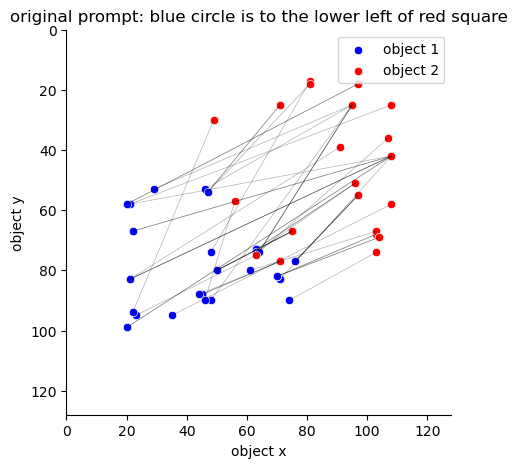

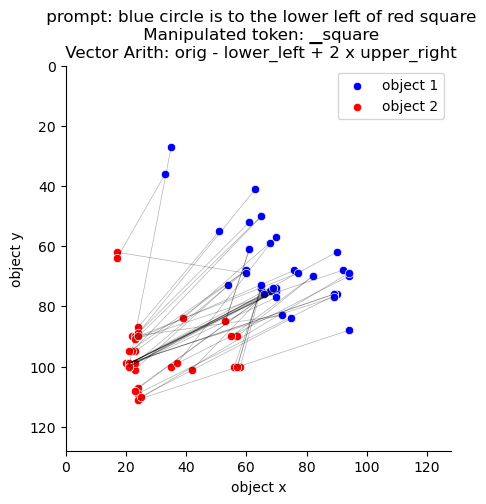

In [14]:
# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == 'blue circle is to the upper right of red square'").index
# alternate_prompt = "blue triangle is to the lower left of red square"# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == 'blue circle is to the upper right of red square'").index
# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == @alternate_prompt").index
# alt_wordvec = wordvec_obj2_mat[alt_prompt_idx, :]
print(prompt)
token_ids = pipeline.tokenizer.encode(prompt, add_special_tokens=True)
token_list = pipeline.tokenizer.convert_ids_to_tokens(token_ids)
target_token_idx = find_word_index(token_list, "square")
formula = "orig - lower_left + 2 x upper_right"
caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
target_wordvec = caption_embeds_tmp[0, [target_token_idx], :] - lower_left_effect_vec + 2 * upper_right_effect_vec

pipeline.set_progress_bar_config(disable=True)

summary_eval_df_list = []
print("without attention masking ", embedding_cache[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(pipeline, [prompt], [scene_info], embedding_cache,
                                                       num_images=49, num_inference_steps=14, guidance_scale=4.5,
                                                       generator_seed=42, color_margin=25, spatial_threshold=5, 
                                                       device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation(eval_df, title=f"original prompt: {prompt}")
saveallforms(manip_figdir,  f"orig_prompt_{prompt.replace(' ', '_')}", figh)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = -1
summary_eval_df["manipulated_token"] = ""
summary_eval_df_list.append(summary_eval_df)

embmask_tmp = embedding_cache[f'base::{prompt}']['emb_mask'].clone()
caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
embedding_cache_copy = deepcopy(embedding_cache)
caption_embeds_tmp[0, [target_token_idx], :] = target_wordvec
embedding_cache_copy[f'base::{prompt}']['emb_mask'] = embmask_tmp
embedding_cache_copy[f'base::{prompt}']['caption_embeds'] = caption_embeds_tmp

print("with attention masking ", embedding_cache_copy[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(pipeline, [prompt], [scene_info], embedding_cache_copy,
                                                    num_images=49, num_inference_steps=14, guidance_scale=4.5,
                                                    generator_seed=42, color_margin=25, spatial_threshold=5, 
                                                    device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation(eval_df, title=f" prompt: {prompt}\n Manipulated token: {token_list[target_token_idx]}\n Vector Arith: {formula}")
# saveallforms(manip_figdir,  f"grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}", figh)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = target_token_idx
summary_eval_df["manipulated_token"] = token_list[target_token_idx]
summary_eval_df_list.append(summary_eval_df)

summary_eval_df = pd.concat(summary_eval_df_list)
# summary_eval_df.to_csv(join(manip_figdir, f"summary_eval_df_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}.csv"), index=False)
summary_eval_df.set_index(["manipulated_token", "manipulated_idx"])

### More detailed 

In [17]:
scene_info

{'color1': 'blue',
 'shape1': 'circle',
 'color2': 'red',
 'shape2': 'square',
 'spatial_relationship': 'lower_left'}

blue circle is to the lower left of red square
without attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408


with attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,41.408,-27.857,70.204,68.245,28.796,96.102


,,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
manipulated_token,manipulated_idx,,,,,,,,,,,,,,
,-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408
▁square,9,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,41.408,-27.857,70.204,68.245,28.796,96.102


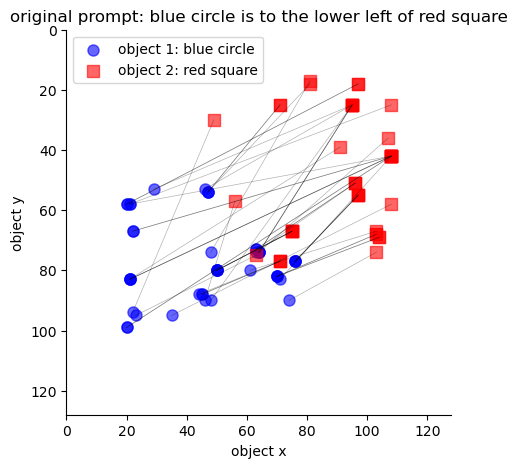

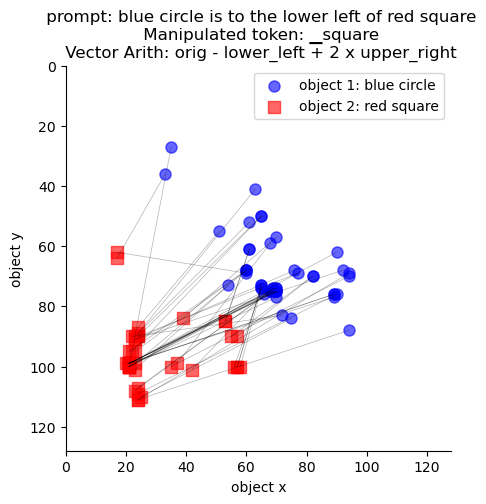

In [24]:
# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == 'blue circle is to the upper right of red square'").index
# alternate_prompt = "blue triangle is to the lower left of red square"# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == 'blue circle is to the upper right of red square'").index
# alt_prompt_idx = prompt_scene_info_all_df.query("prompt == @alternate_prompt").index
# alt_wordvec = wordvec_obj2_mat[alt_prompt_idx, :]
print(prompt)
token_ids = pipeline.tokenizer.encode(prompt, add_special_tokens=True)
token_list = pipeline.tokenizer.convert_ids_to_tokens(token_ids)
target_token_idx = find_word_index(token_list, "square")
formula = "orig - lower_left + 2 x upper_right"
caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
target_wordvec = caption_embeds_tmp[0, [target_token_idx], :] - lower_left_effect_vec + 2 * upper_right_effect_vec

pipeline.set_progress_bar_config(disable=True)

summary_eval_df_list = []
print("without attention masking ", embedding_cache[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(pipeline, [prompt], [scene_info], embedding_cache,
                                                       num_images=49, num_inference_steps=14, guidance_scale=4.5,
                                                       generator_seed=42, color_margin=25, spatial_threshold=5, 
                                                       device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation_with_marker(eval_df, title=f"original prompt: {prompt}",
                                                     obj1_marker=scene_info["shape1"],
                                                     obj2_marker=scene_info["shape2"],
                                                     obj1_color=scene_info["color1"],
                                                     obj2_color=scene_info["color2"],
                                                     alpha=0.6)
saveallforms(manip_figdir,  f"orig_prompt_{prompt.replace(' ', '_')}_with_marker", figh)
eval_df.to_csv(join(manip_figdir, f"eval_df_orig_prompt_{prompt.replace(' ', '_')}.csv"), index=False)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = -1
summary_eval_df["manipulated_token"] = ""
summary_eval_df_list.append(summary_eval_df)

embmask_tmp = embedding_cache[f'base::{prompt}']['emb_mask'].clone()
caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
embedding_cache_copy = deepcopy(embedding_cache)
caption_embeds_tmp[0, [target_token_idx], :] = target_wordvec
embedding_cache_copy[f'base::{prompt}']['emb_mask'] = embmask_tmp
embedding_cache_copy[f'base::{prompt}']['caption_embeds'] = caption_embeds_tmp

print("with attention masking ", embedding_cache_copy[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(pipeline, [prompt], [scene_info], embedding_cache_copy,
                                                    num_images=49, num_inference_steps=14, guidance_scale=4.5,
                                                    generator_seed=42, color_margin=25, spatial_threshold=5, 
                                                    device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation_with_marker(eval_df, title=f" prompt: {prompt}\n Manipulated token: {token_list[target_token_idx]}\n Vector Arith: {formula}",
                                                     obj1_marker=scene_info["shape1"],
                                                     obj2_marker=scene_info["shape2"],
                                                     obj1_color=scene_info["color1"],
                                                     obj2_color=scene_info["color2"],
                                                     alpha=0.6)
saveallforms(manip_figdir,  f"grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}_with_marker", figh)
eval_df.to_csv(join(manip_figdir, f"eval_df_grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}.csv"), index=False)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = target_token_idx
summary_eval_df["manipulated_token"] = token_list[target_token_idx]
summary_eval_df_list.append(summary_eval_df)

summary_eval_df = pd.concat(summary_eval_df_list)
# summary_eval_df.to_csv(join(manip_figdir, f"summary_eval_df_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}.csv"), index=False)
summary_eval_df.set_index(["manipulated_token", "manipulated_idx"])

In [25]:
above_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "above")).to(dtype=torch.bfloat16)
below_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "below")).to(dtype=torch.bfloat16)
left_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "left")).to(dtype=torch.bfloat16)
right_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "right")).to(dtype=torch.bfloat16)
upper_left_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "upper_left")).to(dtype=torch.bfloat16)
lower_left_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "lower_left")).to(dtype=torch.bfloat16)
lower_right_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "lower_right")).to(dtype=torch.bfloat16)
upper_right_effect_vec = torch.tensor(get_feature_effect_vecs(effect_vecs, levels_map, "spatial_relationship", "upper_right")).to(dtype=torch.bfloat16)

without attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408



==== Testing with spatial relationship manipulation: above ====
with attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

...

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,0.918,0.918,1.0,1.0,1.0,1.0,0.918,0.918,33.531,48.918,66.796,79.51,33.265,30.592



==== Testing with spatial relationship manipulation: upper_left ====
with attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,0.612,0.612,0.98,1.0,0.98,0.98,0.612,0.612,-50.25,-11.896,41.583,63.542,91.833,75.438


overall  \
manipulated_token manipulated_idx relation_formula                               
                  -1              original                               1.000   
▁square            9              orig - lower_left + 2 x above          0.000   
                                  orig - lower_left + 2 x below          0.122   
                                  orig - lower_left + 2 x left           0.041   
                                  orig - lower_left + 2 x right          0.122   
                                  orig - lower_left + 2 x lower_left     1.000   
                                  orig - lower_left + 2 x upper_right    0.980   
                                  orig - lower_left + 2 x lower_right    0.918   
                                  orig - lower_left + 2 x upper_left     0.612   

                                                                       overall_loose  \
manipulated_token manipulated_idx relation_formula                                     
                  -1              original                                     1.000   
▁square            9              orig - lower_left + 2 x above                0.041   
                                  orig - lower_left + 2 x below                0.959   
                                  orig - lower_left + 2 x left                 1.000   
                                  orig - lower_left + 2 x right                0.449   
                                  orig - lower_left + 2 x lower_left           1.000   
                                  orig - lower_left + 2 x upper_right          0.980   
                                  orig - lower_left + 2 x lower_right          0.918   
                                  orig - lower_left + 2 x upper_left           0.612   

                                                                       shape  \
manipulated_token manipulated_idx relation_formula                             
                  -1              original                              1.00   
▁square            9              orig - lower_left + 2 x above         1.00   
                                  orig - lower_left + 2 x below         0.98   
                                  orig - lower_left + 2 x left          1.00   
                                  orig - lower_left + 2 x right         0.98   
                                  orig - lower_left + 2 x lower_left    1.00   
                                  orig - lower_left + 2 x upper_right   1.00   
                                  orig - lower_left + 2 x lower_right   1.00   
                                  orig - lower_left + 2 x upper_left    0.98   

                                                                       color  \
manipulated_token manipulated_idx relation_formula                             
                  -1              original                             1.000   
▁square            9              orig - lower_left + 2 x above        1.000   
                                  orig - lower_left + 2 x below        1.000   
                                  orig - lower_left + 2 x left         1.000   
                                  orig - lower_left + 2 x right        0.959   
                                  orig - lower_left + 2 x lower_left   1.000   
                                  orig - lower_left + 2 x upper_right  1.000   
                                  orig - lower_left + 2 x lower_right  1.000   
                                  orig - lower_left + 2 x upper_left   1.000   

                                                                       exist_binding  \
manipulated_token manipulated_idx relation_formula                                     
                  -1              original                                     1.000   
▁square            9              orig - lower_left + 2 x above                1.000   
                                  orig - lower_left + 2 x below                0.980 

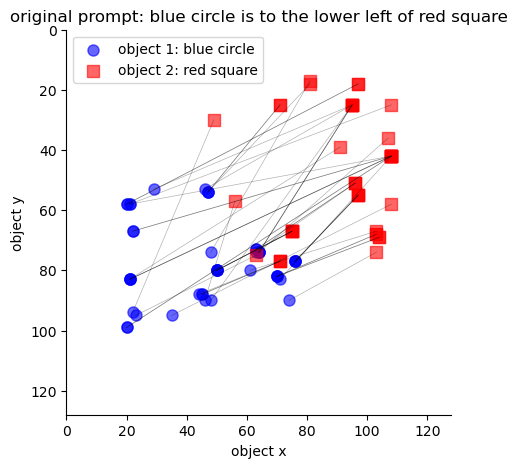

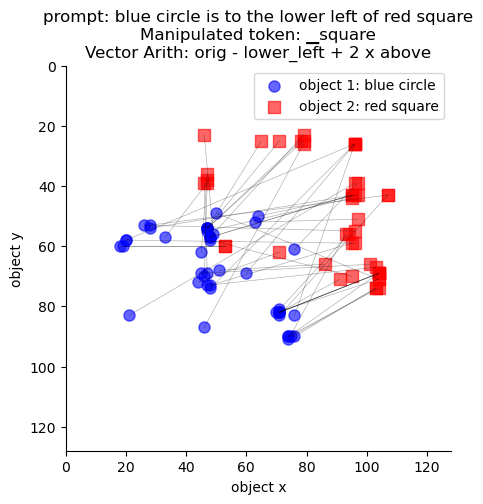

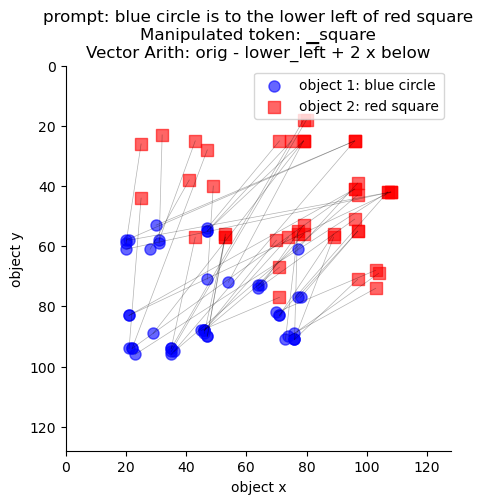

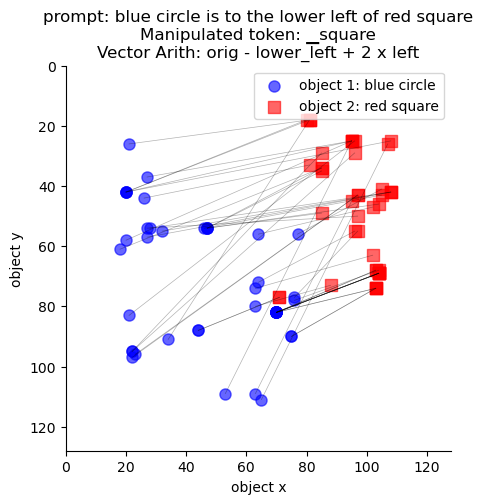

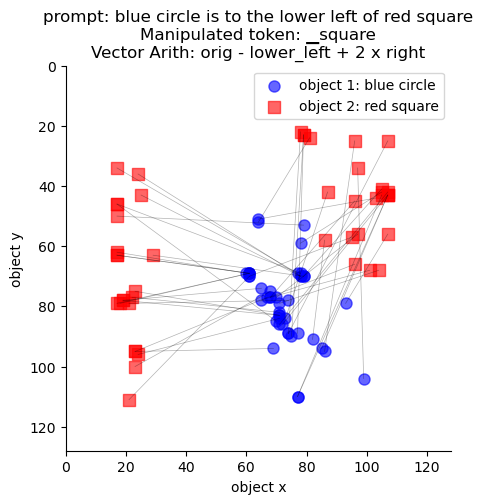

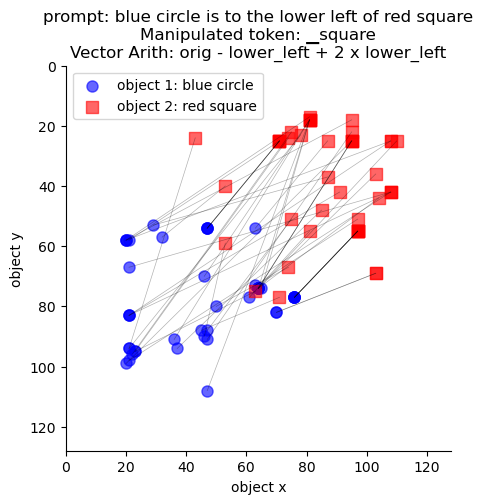

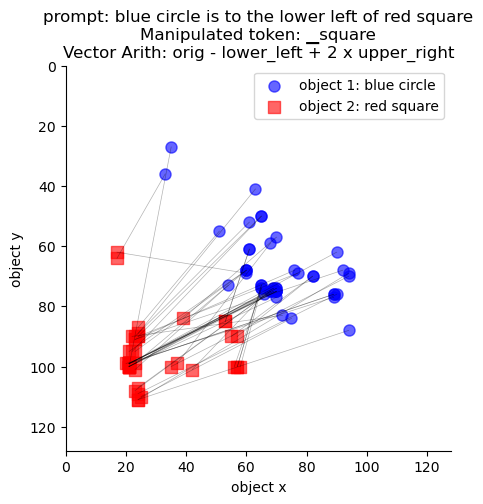

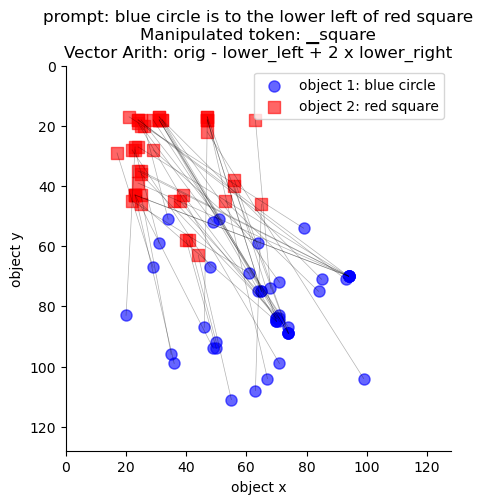

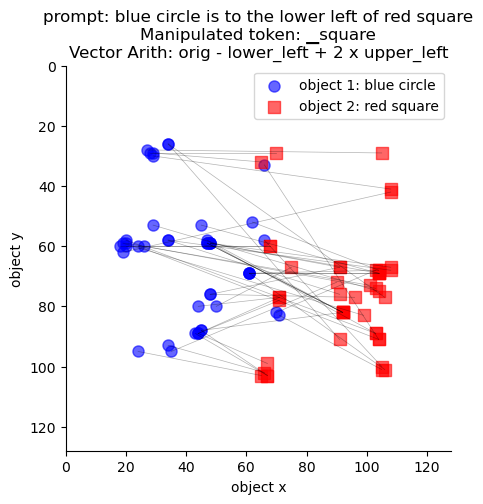

In [27]:
# Learn from previous example and iterate through different relations
# We'll systematically manipulate the prompt's spatial relationship embedding.

relations_to_test = [
    ("above", above_effect_vec),
    ("below", below_effect_vec),
    ("left", left_effect_vec),
    ("right", right_effect_vec),
    ("lower_left", lower_left_effect_vec),
    ("upper_right", upper_right_effect_vec),
    ("lower_right", lower_right_effect_vec),
    ("upper_left", upper_left_effect_vec),
]
relations_to_test = [r for r in relations_to_test if r is not None]

summary_eval_df_list = []

print("without attention masking ", embedding_cache[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(
    pipeline, [prompt], [scene_info], embedding_cache,
    num_images=49, num_inference_steps=14, guidance_scale=4.5,
    generator_seed=42, color_margin=25, spatial_threshold=5, 
    device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation_with_marker(
    eval_df, title=f"original prompt: {prompt}",
    obj1_marker=scene_info["shape1"],
    obj2_marker=scene_info["shape2"],
    obj1_color=scene_info["color1"],
    obj2_color=scene_info["color2"],
    alpha=0.6)
saveallforms(manip_figdir,  f"orig_prompt_{prompt.replace(' ', '_')}_with_marker", figh)
eval_df.to_csv(join(manip_figdir, f"eval_df_orig_prompt_{prompt.replace(' ', '_')}.csv"), index=False)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = -1
summary_eval_df["manipulated_token"] = ""
summary_eval_df["relation_formula"] = "original"
summary_eval_df_list.append(summary_eval_df)

pipeline.set_progress_bar_config(disable=True)
for relation_name, relation_vec in relations_to_test:
    print(f"\n==== Testing with spatial relationship manipulation: {relation_name} ====")
    token_ids = pipeline.tokenizer.encode(prompt, add_special_tokens=True)
    token_list = pipeline.tokenizer.convert_ids_to_tokens(token_ids)
    target_token_idx = find_word_index(token_list, "square")
    # Example manipulation: orig - lower_left + relation_vec*2
    formula = f"orig - lower_left + 2 x {relation_name}"
    caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
    target_wordvec = caption_embeds_tmp[0, [target_token_idx], :] - lower_left_effect_vec + 2 * relation_vec

    embmask_tmp = embedding_cache[f'base::{prompt}']['emb_mask'].clone()
    caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
    embedding_cache_copy = deepcopy(embedding_cache)
    caption_embeds_tmp[0, [target_token_idx], :] = target_wordvec
    embedding_cache_copy[f'base::{prompt}']['emb_mask'] = embmask_tmp
    embedding_cache_copy[f'base::{prompt}']['caption_embeds'] = caption_embeds_tmp
    scene_info_manip = deepcopy(scene_info)
    scene_info_manip["spatial_relationship"] = relation_name
    
    print("with attention masking ", embedding_cache_copy[f'base::{prompt}']['emb_mask'])
    eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, [prompt], [scene_info_manip], embedding_cache_copy,
        num_images=49, num_inference_steps=14, guidance_scale=4.5,
        generator_seed=42, color_margin=25, spatial_threshold=5, 
        device="cuda", weight_dtype=torch.float16)
    figh = visualize_eval_df_object_relation_with_marker(
        eval_df, title=(
            f"prompt: {prompt}\n"
            f"Manipulated token: {token_list[target_token_idx]}"
            f"\nVector Arith: {formula}"
        ),
        obj1_marker=scene_info["shape1"],
        obj2_marker=scene_info["shape2"],
        obj1_color=scene_info["color1"],
        obj2_color=scene_info["color2"],
        alpha=0.6)
    saveallforms(
        manip_figdir,  
        f"grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}_{relation_name}_with_marker", 
        figh)
    eval_df.to_csv(join(manip_figdir, 
        f"eval_df_grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}_{relation_name}.csv"),
        index=False)

    summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
    summary_eval_df["manipulated_idx"] = target_token_idx
    summary_eval_df["manipulated_token"] = token_list[target_token_idx]
    summary_eval_df["relation_formula"] = formula
    summary_eval_df_list.append(summary_eval_df)

summary_eval_df = pd.concat(summary_eval_df_list, ignore_index=True)
# Optionally save or further process the summary dataframe.
summary_eval_df.set_index(["manipulated_token", "manipulated_idx", "relation_formula"])

without attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-44.878,29.551,47.082,76.959,91.959,47.408



==== Testing with spatial relationship manipulation: above ====
with attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,0.98,0.98,1.0,1.0,1.0,1.0,0.98,0.98,38.102,46.531,68.367,84.02,30.265,37.49



==== Testing with spatial relationship manipulation: upper_left ====
with attention masking  tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


Evaluating prompts:   0%|          | 0/1 [00:00<?, ?it/s]

,overall,overall_loose,shape,color,exist_binding,unique_binding,spatial_relationship,spatial_relationship_loose,Dx,Dy,x1,y1,x2,y2
0,0.714,0.714,0.98,1.0,0.98,0.98,0.714,0.714,-39.938,-18.062,40.833,60.521,80.771,78.583


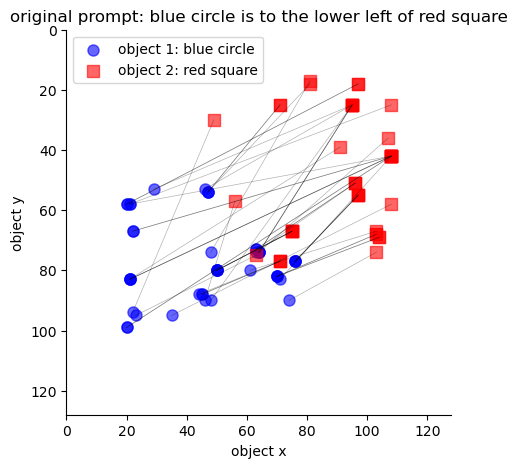

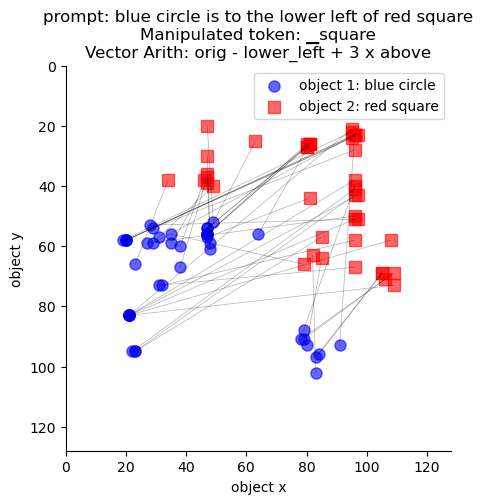

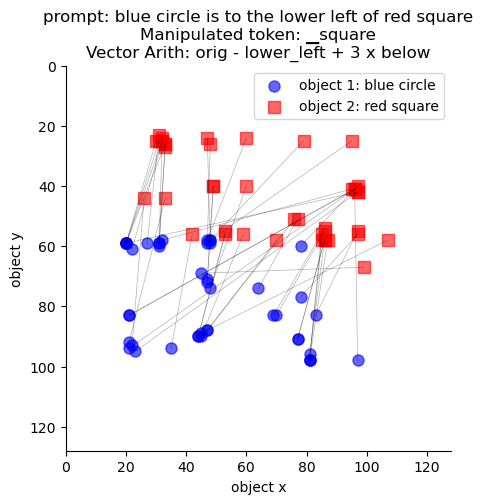

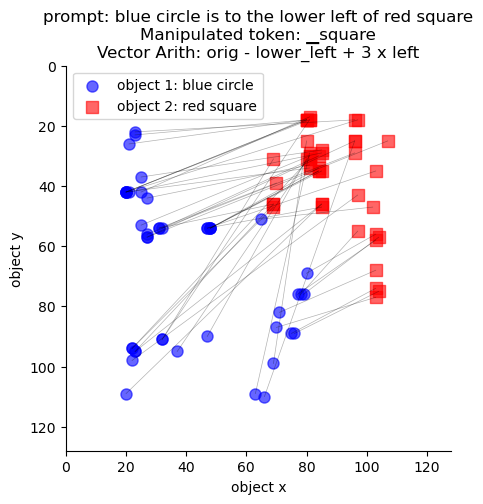

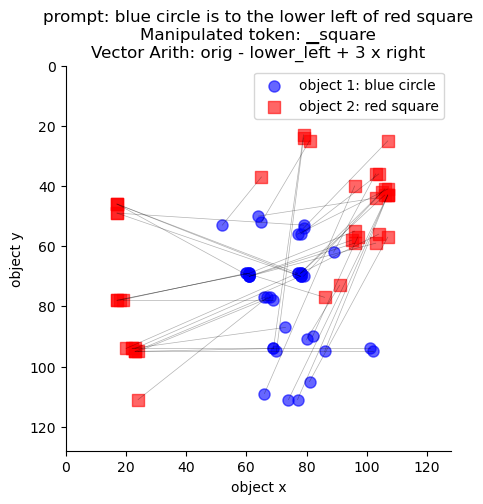

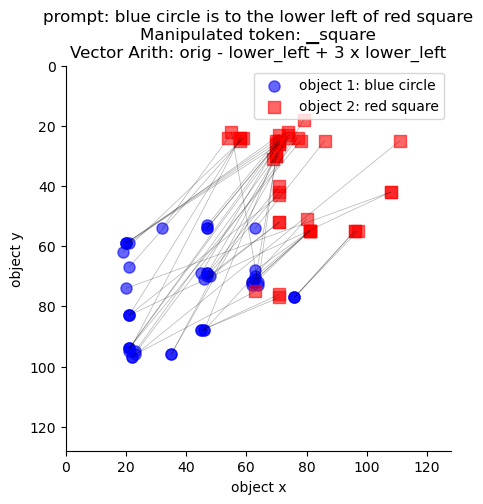

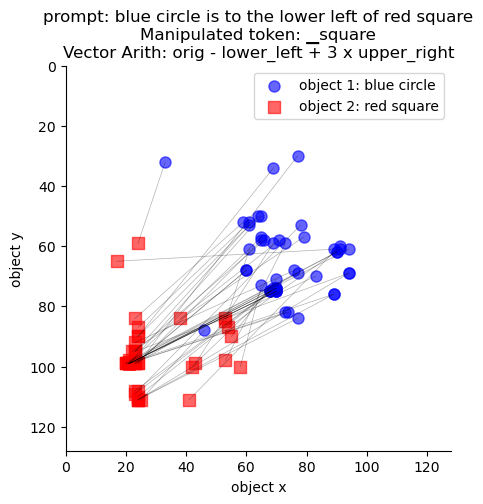

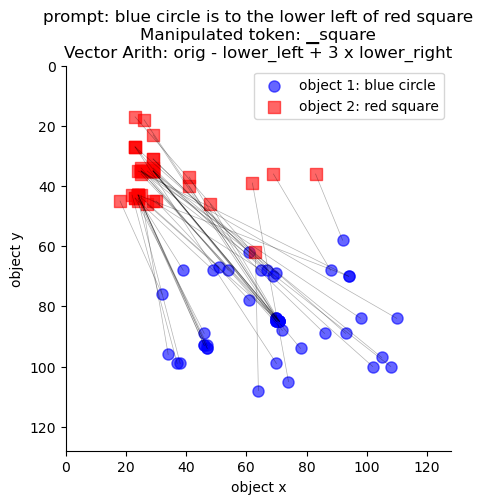

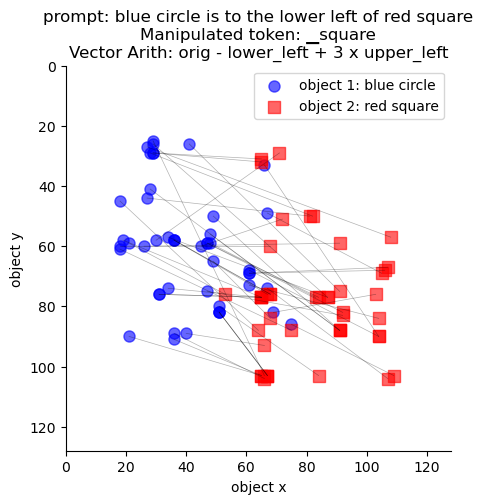

In [29]:
# Learn from previous example and iterate through different relations
# We'll systematically manipulate the prompt's spatial relationship embedding.

relations_to_test = [
    ("above", above_effect_vec),
    ("below", below_effect_vec),
    ("left", left_effect_vec),
    ("right", right_effect_vec),
    ("lower_left", lower_left_effect_vec),
    ("upper_right", upper_right_effect_vec),
    ("lower_right", lower_right_effect_vec),
    ("upper_left", upper_left_effect_vec),
]
relations_to_test = [r for r in relations_to_test if r is not None]

summary_eval_df_list = []

print("without attention masking ", embedding_cache[f'base::{prompt}']['emb_mask'])
eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(
    pipeline, [prompt], [scene_info], embedding_cache,
    num_images=49, num_inference_steps=14, guidance_scale=4.5,
    generator_seed=42, color_margin=25, spatial_threshold=5, 
    device="cuda", weight_dtype=torch.float16)
figh = visualize_eval_df_object_relation_with_marker(
    eval_df, title=f"original prompt: {prompt}",
    obj1_marker=scene_info["shape1"],
    obj2_marker=scene_info["shape2"],
    obj1_color=scene_info["color1"],
    obj2_color=scene_info["color2"],
    alpha=0.6)
saveallforms(manip_figdir,  f"orig_prompt_{prompt.replace(' ', '_')}_with_marker", figh)
eval_df.to_csv(join(manip_figdir, f"eval_df_orig_prompt_{prompt.replace(' ', '_')}.csv"), index=False)

summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
summary_eval_df["manipulated_idx"] = -1
summary_eval_df["manipulated_token"] = ""
summary_eval_df["relation_formula"] = "original"
summary_eval_df_list.append(summary_eval_df)

pipeline.set_progress_bar_config(disable=True)
for relation_name, relation_vec in relations_to_test:
    print(f"\n==== Testing with spatial relationship manipulation: {relation_name} ====")
    token_ids = pipeline.tokenizer.encode(prompt, add_special_tokens=True)
    token_list = pipeline.tokenizer.convert_ids_to_tokens(token_ids)
    target_token_idx = find_word_index(token_list, "square")
    # Example manipulation: orig - lower_left + relation_vec*2
    formula = f"orig - lower_left + 3 x {relation_name}"
    caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
    target_wordvec = caption_embeds_tmp[0, [target_token_idx], :] - lower_left_effect_vec + 3 * relation_vec

    embmask_tmp = embedding_cache[f'base::{prompt}']['emb_mask'].clone()
    caption_embeds_tmp = embedding_cache[f'base::{prompt}']['caption_embeds'].clone()
    embedding_cache_copy = deepcopy(embedding_cache)
    caption_embeds_tmp[0, [target_token_idx], :] = target_wordvec
    embedding_cache_copy[f'base::{prompt}']['emb_mask'] = embmask_tmp
    embedding_cache_copy[f'base::{prompt}']['caption_embeds'] = caption_embeds_tmp
    scene_info_manip = deepcopy(scene_info)
    scene_info_manip["spatial_relationship"] = relation_name
    
    print("with attention masking ", embedding_cache_copy[f'base::{prompt}']['emb_mask'])
    eval_df, object_df = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, [prompt], [scene_info_manip], embedding_cache_copy,
        num_images=49, num_inference_steps=14, guidance_scale=4.5,
        generator_seed=42, color_margin=25, spatial_threshold=5, 
        device="cuda", weight_dtype=torch.float16)
    figh = visualize_eval_df_object_relation_with_marker(
        eval_df, title=(
            f"prompt: {prompt}\n"
            f"Manipulated token: {token_list[target_token_idx]}"
            f"\nVector Arith: {formula}"
        ),
        obj1_marker=scene_info["shape1"],
        obj2_marker=scene_info["shape2"],
        obj1_color=scene_info["color1"],
        obj2_color=scene_info["color2"],
        alpha=0.6)
    saveallforms(
        manip_figdir,  
        f"grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}_{relation_name}_with_marker", 
        figh)
    eval_df.to_csv(join(manip_figdir, 
        f"eval_df_grafted_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_{formula.replace(' ', '_')}_{relation_name}.csv"),
        index=False)

    summary_eval_df = print_evaluation_summary_concise(eval_df, group_by_prompt=False)
    summary_eval_df["manipulated_idx"] = target_token_idx
    summary_eval_df["manipulated_token"] = token_list[target_token_idx]
    summary_eval_df["relation_formula"] = formula
    summary_eval_df_list.append(summary_eval_df)

summary_eval_df = pd.concat(summary_eval_df_list, ignore_index=True)
# Optionally save or further process the summary dataframe.
summary_eval_df.set_index(["manipulated_token", "manipulated_idx", "relation_formula"])
summary_eval_df.to_csv(join(manip_figdir, f"summary_eval_df_prompt_{prompt.replace(' ', '_')}_graft_{token_list[target_token_idx]}_vecarith_all_relations_3x.csv"), index=False)

In [30]:
summary_eval_df.set_index(["manipulated_token", "manipulated_idx", "relation_formula"])

overall  \
manipulated_token manipulated_idx relation_formula                               
                  -1              original                               1.000   
▁square            9              orig - lower_left + 3 x above          0.000   
                                  orig - lower_left + 3 x below          0.265   
                                  orig - lower_left + 3 x left           0.061   
                                  orig - lower_left + 3 x right          0.102   
                                  orig - lower_left + 3 x lower_left     0.918   
                                  orig - lower_left + 3 x upper_right    0.980   
                                  orig - lower_left + 3 x lower_right    0.980   
                                  orig - lower_left + 3 x upper_left     0.714   

                                                                       overall_loose  \
manipulated_token manipulated_idx relation_formula                                     
                  -1              original                                     1.000   
▁square            9              orig - lower_left + 3 x above                0.020   
                                  orig - lower_left + 3 x below                0.918   
                                  orig - lower_left + 3 x left                 0.959   
                                  orig - lower_left + 3 x right                0.367   
                                  orig - lower_left + 3 x lower_left           0.918   
                                  orig - lower_left + 3 x upper_right          0.980   
                                  orig - lower_left + 3 x lower_right          0.980   
                                  orig - lower_left + 3 x upper_left           0.714   

                                                                       shape  \
manipulated_token manipulated_idx relation_formula                             
                  -1              original                             1.000   
▁square            9              orig - lower_left + 3 x above        0.939   
                                  orig - lower_left + 3 x below        0.959   
                                  orig - lower_left + 3 x left         0.959   
                                  orig - lower_left + 3 x right        0.898   
                                  orig - lower_left + 3 x lower_left   0.939   
                                  orig - lower_left + 3 x upper_right  1.000   
                                  orig - lower_left + 3 x lower_right  1.000   
                                  orig - lower_left + 3 x upper_left   0.980   

                                                                       color  \
manipulated_token manipulated_idx relation_formula                             
                  -1              original                             1.000   
▁square            9              orig - lower_left + 3 x above        0.980   
                                  orig - lower_left + 3 x below        1.000   
                                  orig - lower_left + 3 x left         1.000   
                                  orig - lower_left + 3 x right        0.939   
                                  orig - lower_left + 3 x lower_left   1.000   
                                  orig - lower_left + 3 x upper_right  1.000   
                                  orig - lower_left + 3 x lower_right  1.000   
                                  orig - lower_left + 3 x upper_left   1.000   

                                                                       exist_binding  \
manipulated_token manipulated_idx relation_formula                                     
                  -1              original                                     1.000   
▁square            9              orig - lower_left + 3 x above                0.918   
                                  orig - lower_left + 3 x below                0.959 